In [1]:
# Initialisation de la session Spark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType, StringType

spark = SparkSession.builder \
    .appName("PAP_Immobilier_ETL") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version : {spark.version}")
print("Session initialisée avec succès.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/11 11:43:53 WARN Utils: Your hostname, codespaces-a08075, resolves to a loopback address: 127.0.0.1; using 10.0.1.245 instead (on interface eth0)
26/04/11 11:43:53 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/11 11:43:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version : 4.1.1
Session initialisée avec succès.


In [3]:
# Chargement du dataset PAP
CSV_PATH = "PAP_clean.csv"  

df_raw = spark.read.csv(
    CSV_PATH,
    sep=";",
    header=True,
    inferSchema=True,
    quote='"',
    escape='"',
    multiLine=True   
)

print(f"Dimensions : {df_raw.count()} lignes et {len(df_raw.columns)} colonnes")

Dimensions : 1221 lignes et 10 colonnes


# Nettoyage

In [4]:
# Valeurs manquantes
from pyspark.sql.functions import col, isnan, when, count

total = df_raw.count()

null_counts = df_raw.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    if df_raw.schema[c].dataType.typeName() in ('double', 'float', 'integer', 'long')
    else count(when(col(c).isNull() | (col(c) == ''), c)).alias(c)
    for c in df_raw.columns
])

print("Valeurs manquantes par colonne :")
null_counts.show()

# Taux de complétude
null_pdf = null_counts.toPandas().T
null_pdf.columns = ["nb_null"]
null_pdf["taux_null_%"] = (null_pdf["nb_null"] / total * 100).round(2)
print(null_pdf)

Valeurs manquantes par colonne :
+----+-------+---------+-----------+-----------+-----------+---------+------+-----+-----------+
|prix|surface|nb_pieces|nb_chambres|description|transaction|type_bien|source|ville|code_postal|
+----+-------+---------+-----------+-----------+-----------+---------+------+-----+-----------+
|   0|     60|      312|        281|          0|          0|        0|     0|    0|          0|
+----+-------+---------+-----------+-----------+-----------+---------+------+-----+-----------+

             nb_null  taux_null_%
prix               0         0.00
surface           60         4.91
nb_pieces        312        25.55
nb_chambres      281        23.01
description        0         0.00
transaction        0         0.00
type_bien          0         0.00
source             0         0.00
ville              0         0.00
code_postal        0         0.00


In [5]:
# Suppression des doublons
avant = df_raw.count()

# Doublons exacts (test sur toutes colonnes)
df_dedup = df_raw.dropDuplicates()

apres = df_dedup.count()
print(f"Doublons supprimés : {avant - apres} (nombre de lignes avant : {avant}, nombre de lignes après : {apres})")

Doublons supprimés : 255 (nombre de lignes avant : 1221, nombre de lignes après : 966)


In [6]:
# Gestion des valeurs manquantes
from pyspark.sql.functions import median

# Remplace par la médiane 
med_surface = df_dedup.approxQuantile("surface", [0.5], 0.01)[0]
med_pieces  = df_dedup.approxQuantile("nb_pieces",  [0.5], 0.01)[0]
med_chambres = df_dedup.approxQuantile("nb_chambres", [0.5], 0.01)[0]

df_clean = df_dedup.fillna({
    "surface":      med_surface,
    "nb_pieces":    med_pieces,
    "nb_chambres":  med_chambres,
    "description":  "",          # texte vide si absent
    "type_bien":    "inconnu",
    "transaction":  "inconnu"
})

# Suppression lignes sans prix
df_clean = df_clean.filter(col("prix").isNotNull() & (col("prix") > 0))

# Vérification
df_clean.select([count(when(col(c).isNull(), c)).alias(c) for c in df_clean.columns]).show()

+----+-------+---------+-----------+-----------+-----------+---------+------+-----+-----------+
|prix|surface|nb_pieces|nb_chambres|description|transaction|type_bien|source|ville|code_postal|
+----+-------+---------+-----------+-----------+-----------+---------+------+-----+-----------+
|   0|      0|        0|          0|          0|          0|        0|     0|    0|          0|
+----+-------+---------+-----------+-----------+-----------+---------+------+-----+-----------+



In [7]:
# Méthode IQR sur prix et surface
def remove_outliers_iqr(df, col_name, factor=3.0):
    q1, q3 = df.approxQuantile(col_name, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    print(f"  {col_name}: [{lower:.0f}, {upper:.0f}]")
    return df.filter((col(col_name) >= lower) & (col(col_name) <= upper))

print("Bornes acceptées (IQR x3) :")
df_clean = remove_outliers_iqr(df_clean, "prix")
df_clean = remove_outliers_iqr(df_clean, "surface")

print(f"Après filtrage outliers : {df_clean.count()} lignes")

Bornes acceptées (IQR x3) :
  prix: [-1281920, 1712190]
  surface: [-150, 305]
Après filtrage outliers : 942 lignes


# MapReduce sur les descriptions

In [8]:
# Prétraitement textuel
import re
from pyspark.sql.functions import udf, lower, regexp_replace, trim
from pyspark.sql.types import StringType

# Stopwords français (liste étendue)
STOPWORDS_FR = set([
    "le", "la", "les", "de", "du", "des", "un", "une", "et", "en", "au", "aux",
    "à", "est", "par", "sur", "dans", "avec", "pour", "qui", "que", "son", "sa",
    "ses", "se", "il", "elle", "ils", "elles", "je", "tu", "nous", "vous", "on",
    "ce", "cette", "ces", "mon", "ma", "mes", "ton", "ta", "tes", "plus", "très",
    "bien", "tout", "ou", "si", "ne", "pas", "y", "d", "l", "j", "s", "m", "n",
    "c", "qu", "bel", "beau", "belle", "aussi", "dont", "même", "entre", "être"
])

def clean_text(text):
    if not text:
        return ""
    # Minuscules, suppression ponctuation et caractères spéciaux
    text = text.lower()
    text = re.sub(r"[^a-zàâäéèêëîïôùûüç\s]", " ", text)
    # Suppression mots courts (<3 chars) et stopwords
    words = [w for w in text.split() if len(w) >= 3 and w not in STOPWORDS_FR]
    return " ".join(words)

clean_text_udf = udf(clean_text, StringType())

df_nlp = df_clean.withColumn("description_clean", clean_text_udf(col("description")))
df_nlp.select("description", "description_clean").show(3, truncate=100)

+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+
|                                                                                         description|                                                                                   description_clean|
+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+
|Au pied du métro Tolbiac, charmant 2 pièces dans l'ancien avec cachet. Situé au 1er étage d'un im...|pied métro tolbiac charmant pièces ancien cachet situé étage immeuble ancien entretenu cet appart...|
|Rue de Maubeuge, dans un très bel immeuble pierre de taille, au dernier étage avec ascenseur, une...|rue maubeuge immeuble pierre taille dernier étage ascenseur chambre classée bon ét

In [9]:
# Top-K mots les plus fréquents
from pyspark.sql.functions import explode, split

K = 30  # Nombre de mots à extraire

# MAP : tokenisation – une ligne par mot
words_df = df_nlp \
    .select(explode(split(col("description_clean"), "\\s+")).alias("mot")) \
    .filter(col("mot") != "")

# REDUCE : comptage agrégé
word_freq = words_df \
    .groupBy("mot") \
    .agg(count("*").alias("frequence")) \
    .orderBy(col("frequence").desc())

print(f"Top {K} mots les plus fréquents dans les descriptions :")
top_k = word_freq.limit(K)
top_k.show(K, truncate=False)

Top 30 mots les plus fréquents dans les descriptions :


+-----------+---------+
|mot        |frequence|
+-----------+---------+
|maison     |303      |
|appartement|279      |
|situé      |249      |
|étage      |220      |
|calme      |212      |
|pièces     |189      |
|rue        |163      |
|quartier   |151      |
|cuisine    |143      |
|terrain    |143      |
|paris      |137      |
|immeuble   |128      |
|pied       |115      |
|chambres   |110      |
|lumineux   |109      |
|salle      |105      |
|proximité  |101      |
|entièrement|100      |
|proche     |98       |
|centre     |96       |
|commerces  |95       |
|métro      |94       |
|parking    |92       |
|ascenseur  |88       |
|ville      |87       |
|jardin     |87       |
|résidence  |86       |
|ème        |84       |
|studio     |82       |
|min        |82       |
+-----------+---------+



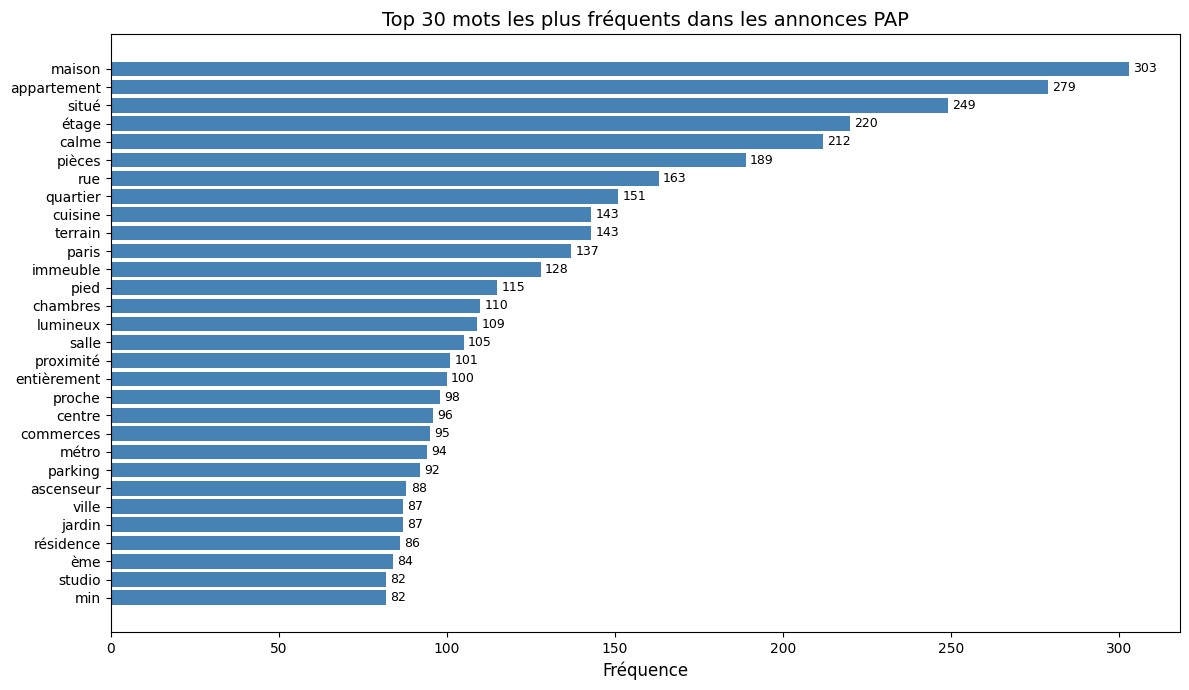

In [10]:
# Visualisation du Top-K
import matplotlib.pyplot as plt

top_k_pd = top_k.toPandas()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_k_pd["mot"][::-1], top_k_pd["frequence"][::-1], color="steelblue")
ax.set_xlabel("Fréquence", fontsize=12)
ax.set_title(f"Top {K} mots les plus fréquents dans les annonces PAP", fontsize=14)
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("top_k_mots.png", dpi=150)
plt.show()

In [11]:
# Analyse par type de bien
from pyspark.sql.functions import concat_ws, collect_list

# Top 10 mots par type de bien
words_by_type = df_nlp \
    .select("type_bien", explode(split(col("description_clean"), "\\s+")).alias("mot")) \
    .filter(col("mot") != "") \
    .groupBy("type_bien", "mot") \
    .agg(count("*").alias("freq"))

from pyspark.sql.window import Window
from pyspark.sql.functions import rank as spark_rank

window = Window.partitionBy("type_bien").orderBy(col("freq").desc())
top_by_type = words_by_type \
    .withColumn("rang", spark_rank().over(window)) \
    .filter(col("rang") <= 10) \
    .orderBy("type_bien", "rang")

print("Top 10 mots par type de bien :")
top_by_type.show(50, truncate=False)

Top 10 mots par type de bien :
+------------+-----------+----+----+
|type_bien   |mot        |freq|rang|
+------------+-----------+----+----+
|appartements|appartement|276 |1   |
|appartements|situé      |217 |2   |
|appartements|étage      |191 |3   |
|appartements|pièces     |161 |4   |
|appartements|rue        |148 |5   |
|appartements|calme      |128 |6   |
|appartements|paris      |127 |7   |
|appartements|immeuble   |127 |7   |
|appartements|quartier   |107 |9   |
|appartements|lumineux   |100 |10  |
|maisons     |maison     |279 |1   |
|maisons     |terrain    |138 |2   |
|maisons     |calme      |84  |3   |
|maisons     |cuisine    |65  |4   |
|maisons     |située     |61  |5   |
|maisons     |chambres   |60  |6   |
|maisons     |maisons    |54  |7   |
|maisons     |ville      |53  |8   |
|maisons     |surface    |50  |9   |
|maisons     |votre      |46  |10  |
+------------+-----------+----+----+



# Feature Engineering

In [12]:
from pyspark.sql.functions import length, size, split as spark_split, log1p

df_features = df_clean \
    .withColumn("prix_m2",      (col("prix") / col("surface")).cast("float")) \
    .withColumn("log_prix",     log1p(col("prix").cast("double"))) \
    .withColumn("ratio_ch_pi",  (col("nb_chambres") / col("nb_pieces")).cast("float")) \
    .withColumn("len_desc",     length(col("description"))) \
    .withColumn("nb_mots_desc", size(spark_split(col("description"), "\\s+"))) \
    .withColumn("departement",  (col("code_postal") / 1000).cast("integer"))

# Flags booléens à partir des mots-clés repérés plus haut
keywords = ["balcon", "parking", "cave", "ascenseur", "terrasse", 
            "lumineux", "rénové", "meublé", "jardin", "duplex"]

for kw in keywords:
    df_features = df_features.withColumn(
        f"flag_{kw}",
        when(lower(col("description")).contains(kw), 1).otherwise(0)
    )

print("Colonnes du dataset enrichi :")
print(df_features.columns)

Colonnes du dataset enrichi :
['prix', 'surface', 'nb_pieces', 'nb_chambres', 'description', 'transaction', 'type_bien', 'source', 'ville', 'code_postal', 'prix_m2', 'log_prix', 'ratio_ch_pi', 'len_desc', 'nb_mots_desc', 'departement', 'flag_balcon', 'flag_parking', 'flag_cave', 'flag_ascenseur', 'flag_terrasse', 'flag_lumineux', 'flag_rénové', 'flag_meublé', 'flag_jardin', 'flag_duplex']


# Statistiques descriptives & exploration

In [13]:
print("Statistiques descriptives globales :")
df_features.select("prix", "surface", "nb_pieces", "nb_chambres", "prix_m2").describe().show()

print("\nDistribution par ville (Top 15) :")
df_features.groupBy("ville") \
    .agg(
        count("*").alias("nb_annonces"),
        F.round(F.avg("prix"), 0).alias("prix_moyen"),
        F.round(F.avg("prix_m2"), 0).alias("prix_m2_moyen")
    ) \
    .orderBy(col("nb_annonces").desc()) \
    .show(15)

print("\nDistribution par type de bien :")
df_features.groupBy("type_bien", "transaction") \
    .agg(
        count("*").alias("nb_annonces"),
        F.round(F.avg("prix"), 0).alias("prix_moyen"),
        F.round(F.avg("prix_m2"), 0).alias("prix_m2_moyen")
    ) \
    .orderBy("type_bien", "transaction") \
    .show()

print("\nPrévalence des équipements :")
flag_cols = [f"flag_{kw}" for kw in keywords]
df_features.select([F.round(F.avg(c) * 100, 1).alias(c) for c in flag_cols]).show()

Statistiques descriptives globales :


26/04/11 11:47:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+-----------------+------------------+------------------+------------------+
|summary|             prix|          surface|         nb_pieces|       nb_chambres|           prix_m2|
+-------+-----------------+-----------------+------------------+------------------+------------------+
|  count|              942|              942|               942|               942|               942|
|   mean|270242.0774946921|84.15154989384285|3.2632696390658174|  2.73036093418259|3647.1484735213267|
| stddev|337140.0042313351|51.17693538650881|1.4632258517437193|1.1052534570578536| 4274.357387779158|
|    min|               40|              7.0|                 1|                 1|               0.5|
|    max|          1700000|            300.0|                10|                 6|          20878.21|
+-------+-----------------+-----------------+------------------+------------------+------------------+


Distribution par ville (Top 15) :
+--------------------+-----------+---

+-----------+------------+---------+--------------+-------------+-------------+-----------+-----------+-----------+-----------+
|flag_balcon|flag_parking|flag_cave|flag_ascenseur|flag_terrasse|flag_lumineux|flag_rénové|flag_meublé|flag_jardin|flag_duplex|
+-----------+------------+---------+--------------+-------------+-------------+-----------+-----------+-----------+-----------+
|        4.4|         8.1|      1.9|           9.7|          6.6|         11.4|        9.6|       13.7|        8.8|        2.8|
+-----------+------------+---------+--------------+-------------+-------------+-----------+-----------+-----------+-----------+



In [15]:
# Fermeture de la session
spark.stop()
print("Session Spark fermée.")

Session Spark fermée.
